In [1]:
import numpy as np
from sklearn.decomposition import PCA

from morl_behavior_objective.analysis.metrics_clean import compute_zadu_metrics
from morl_behavior_objective.utils import load_ground_truth_data
from morl_behavior_objective.utils import load_transformer_embeddings

/Users/ffelte/Documents/Behavior-vs-Objective-Space/venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/ffelte/Documents/Behavior-vs-Objective-Space/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment deep-sea-treasure-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/Users/ffelte/Documents/Behavior-vs-Objective-Space/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment deep-sea-treasure-concave-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/Users/ffelte/Doc

## Load all the data

### Ground Truth and Returns embeddings

In [2]:
# Configuration for datasets
datasets = {
    "left_right": {
        "name": "left_right_dst",
        "num_files": 6,
        "embedding_path": "../../trajectories/left_right_dst/embeddings/left_right_dst_3D_l2_embeddings_e501_pf_t_shorter.json"
    },
    "concave": {
        "name": "dst_concave",
        "num_files": 10,
        "embedding_path": "../../trajectories/dst_concave/embeddings/dst_concave_3D_l2_embeddings_e501_pf_t_shorter.json"
    },
    "smooth": {
        "name": "smooth",
        "num_files": 10,
        "embedding_path": "../../trajectories/smooth/embeddings/smooth_3D_l2_embeddings_e501_pf_t_shorter.json"
    }
}

# Load ground truth data
all_gt_emb, all_returns_lr = load_ground_truth_data(
    datasets["left_right"]["name"],
    datasets["left_right"]["num_files"]
)

all_gt_emb_concave, all_returns_concave = load_ground_truth_data(
    datasets["concave"]["name"],
    datasets["concave"]["num_files"]
)

all_gt_emb_smooth, all_returns_smooth = load_ground_truth_data(
    datasets["smooth"]["name"],
    datasets["smooth"]["num_files"]
)

# Load transformer embeddings
all_t_emb_3D, _ = load_transformer_embeddings(datasets["left_right"]["embedding_path"])  # noqa: N816
all_t_emb_3D_concave, _ = load_transformer_embeddings(datasets["concave"]["embedding_path"])  # noqa: N816
all_t_emb_smooth_new, _ = load_transformer_embeddings(datasets["smooth"]["embedding_path"])

# Print summary
print("Ground truth data loaded successfully:")
print(f" Ground truth embeddings Left right:  all_gt_emb shape: {all_gt_emb.shape}")
print(f" Ground truth returns Left right:  all_returns_lr shape: {all_returns_lr.shape}")
print(f" Ground truth embeddings Concave:  all_gt_emb_concave shape: {all_gt_emb_concave.shape}")
print(f" Ground truth returns Concave:  all_returns_concave shape: {all_returns_concave.shape}")
print(f" Ground truth embeddings Smooth:  all_gt_emb_smooth shape: {all_gt_emb_smooth.shape}")
print(f" Ground truth returns Smooth:  all_returns_smooth shape: {all_returns_smooth.shape}")
print("\nTransformer embeddings loaded successfully:")
print(f" Transformer embeddings Left right 3D:  all_t_emb_3D shape: {all_t_emb_3D.shape}")
print(f" Transformer embeddings Concave 3D:  all_t_emb_3D_concave shape: {all_t_emb_3D_concave.shape}")
print(f" Transformer embeddings Smooth new:  all_t_emb_smooth_new shape: {all_t_emb_smooth_new.shape}")


Ground truth data loaded successfully:
 Ground truth embeddings Left right:  all_gt_emb shape: (6, 2)
 Ground truth returns Left right:  all_returns_lr shape: (6, 2)
 Ground truth embeddings Concave:  all_gt_emb_concave shape: (10, 2)
 Ground truth returns Concave:  all_returns_concave shape: (10, 2)
 Ground truth embeddings Smooth:  all_gt_emb_smooth shape: (10, 2)
 Ground truth returns Smooth:  all_returns_smooth shape: (10, 2)

Transformer embeddings loaded successfully:
 Transformer embeddings Left right 3D:  all_t_emb_3D shape: (6, 3)
 Transformer embeddings Concave 3D:  all_t_emb_3D_concave shape: (10, 3)
 Transformer embeddings Smooth new:  all_t_emb_smooth_new shape: (10, 3)


## Trustworthiness and Continuity

In [5]:

print("=== ZADU METRICS COMPUTATION ===")

# 1. Raw metrics
print("\n--- RAW METRICS ---")
print("Left-right: Returns vs GTE:", compute_zadu_metrics(all_returns_lr, all_gt_emb))
print("Concave: Returns vs GTE:", compute_zadu_metrics(all_returns_concave, all_gt_emb_concave))
print("Left-right: Returns vs TE 3D:", compute_zadu_metrics(all_returns_lr, all_t_emb_3D))
print("Concave: Returns vs TE:", compute_zadu_metrics(all_returns_concave, all_t_emb_3D_concave))
print("Left-right: GTE vs TE 3D:", compute_zadu_metrics(all_gt_emb, all_t_emb_3D))
print("Concave: GTE vs TE 3D:", compute_zadu_metrics(all_gt_emb_concave, all_t_emb_3D_concave))
print("Smooth: Returns vs TE:", compute_zadu_metrics(all_returns_smooth, all_t_emb_smooth_new))
print("Smooth: Returns vs GTE:", compute_zadu_metrics(all_returns_smooth, all_gt_emb_smooth))
print("Smooth: GTE vs TE:", compute_zadu_metrics(all_gt_emb_smooth, all_t_emb_smooth_new))






=== ZADU METRICS COMPUTATION ===

--- RAW METRICS ---
ZADU metrics computed successfully
Left-right: Returns vs GTE: [{'trustworthiness': 0.5666666666666665, 'continuity': 0.5}, {'mrre_false': 0.5897435897435898, 'mrre_missing': 0.5}]
ZADU metrics computed successfully
Concave: Returns vs GTE: [{'trustworthiness': 0.8923076923076924, 'continuity': 0.9538461538461538}, {'mrre_false': 0.8800000000000001, 'mrre_missing': 0.9280000000000002}]
ZADU metrics computed successfully
Left-right: Returns vs TE 3D: [{'trustworthiness': 0.5666666666666665, 'continuity': 0.6333333333333333}, {'mrre_false': 0.6538461538461539, 'mrre_missing': 0.6666666666666666}]
ZADU metrics computed successfully
Concave: Returns vs TE: [{'trustworthiness': 0.8384615384615385, 'continuity': 0.953846153846154}, {'mrre_false': 0.8, 'mrre_missing': 0.9279999999999999}]
ZADU metrics computed successfully
Left-right: GTE vs TE 3D: [{'trustworthiness': 1.0, 'continuity': 1.0}, {'mrre_false': 0.8846153846153846, 'mrre_missi

In [6]:

print("=== ZADU METRICS COMPUTATION ===")

# 1. Raw metrics
print("\n--- Left right ---")

print("Left-right: Returns vs GTE:", compute_zadu_metrics(all_returns_lr, all_gt_emb))
print("Left-right: Returns vs TE 3D:", compute_zadu_metrics(all_returns_lr, all_t_emb_3D))
print("Left-right: GTE vs TE 3D:", compute_zadu_metrics(all_gt_emb, all_t_emb_3D))


print("\n--- Concave ---")
print("Concave: Returns vs GTE:", compute_zadu_metrics(all_returns_concave, all_gt_emb_concave))
print("Concave: Returns vs TE 3D:", compute_zadu_metrics(all_returns_concave, all_t_emb_3D_concave))
print("Concave: GTE vs TE 3D:", compute_zadu_metrics(all_gt_emb_concave, all_t_emb_3D_concave))


print("\n--- Smooth ---")
print("Smooth: Returns vs TE:", compute_zadu_metrics(all_returns_smooth, all_t_emb_smooth_new))
print("Smooth: Returns vs GTE:", compute_zadu_metrics(all_returns_smooth, all_gt_emb_smooth))
print("Smooth: GTE vs TE:", compute_zadu_metrics(all_gt_emb_smooth, all_t_emb_smooth_new))

=== ZADU METRICS COMPUTATION ===

--- Left right ---
ZADU metrics computed successfully
Left-right: Returns vs GTE: [{'trustworthiness': 0.5666666666666665, 'continuity': 0.5}, {'mrre_false': 0.5897435897435898, 'mrre_missing': 0.5}]
ZADU metrics computed successfully
Left-right: Returns vs TE 3D: [{'trustworthiness': 0.5666666666666665, 'continuity': 0.6333333333333333}, {'mrre_false': 0.6538461538461539, 'mrre_missing': 0.6666666666666666}]
ZADU metrics computed successfully
Left-right: GTE vs TE 3D: [{'trustworthiness': 1.0, 'continuity': 1.0}, {'mrre_false': 0.8846153846153846, 'mrre_missing': 0.8846153846153846}]

--- Concave ---
ZADU metrics computed successfully
Concave: Returns vs GTE: [{'trustworthiness': 0.8923076923076924, 'continuity': 0.9538461538461538}, {'mrre_false': 0.8800000000000001, 'mrre_missing': 0.9280000000000002}]
ZADU metrics computed successfully
Concave: Returns vs TE 3D: [{'trustworthiness': 0.8384615384615385, 'continuity': 0.953846153846154}, {'mrre_false

### PCA on TE 

In [7]:
pca = PCA(n_components=2)
all_t_emb_concave_2d = pca.fit_transform(all_t_emb_3D_concave)
all_t_emb_2d = pca.fit_transform(all_t_emb_3D)
zadu_metrics_concave_2d = compute_zadu_metrics(all_gt_emb_concave, all_t_emb_concave_2d)
print(f"GTE vs TE Metrics for concave 2D: {zadu_metrics_concave_2d}")
zadu_metrics_ls_2d = compute_zadu_metrics(all_gt_emb, all_t_emb_2d)
print(f"GTE vs TE Metrics for left_right 2D: {zadu_metrics_ls_2d}")

ZADU metrics computed successfully
GTE vs TE Metrics for concave 2D: [{'trustworthiness': 0.8692307692307691, 'continuity': 0.9461538461538463}, {'mrre_false': 0.868, 'mrre_missing': 0.9400000000000001}]
ZADU metrics computed successfully
GTE vs TE Metrics for left_right 2D: [{'trustworthiness': 1.0, 'continuity': 1.0}, {'mrre_false': 0.8846153846153846, 'mrre_missing': 0.8846153846153846}]


### Visualize embeddings

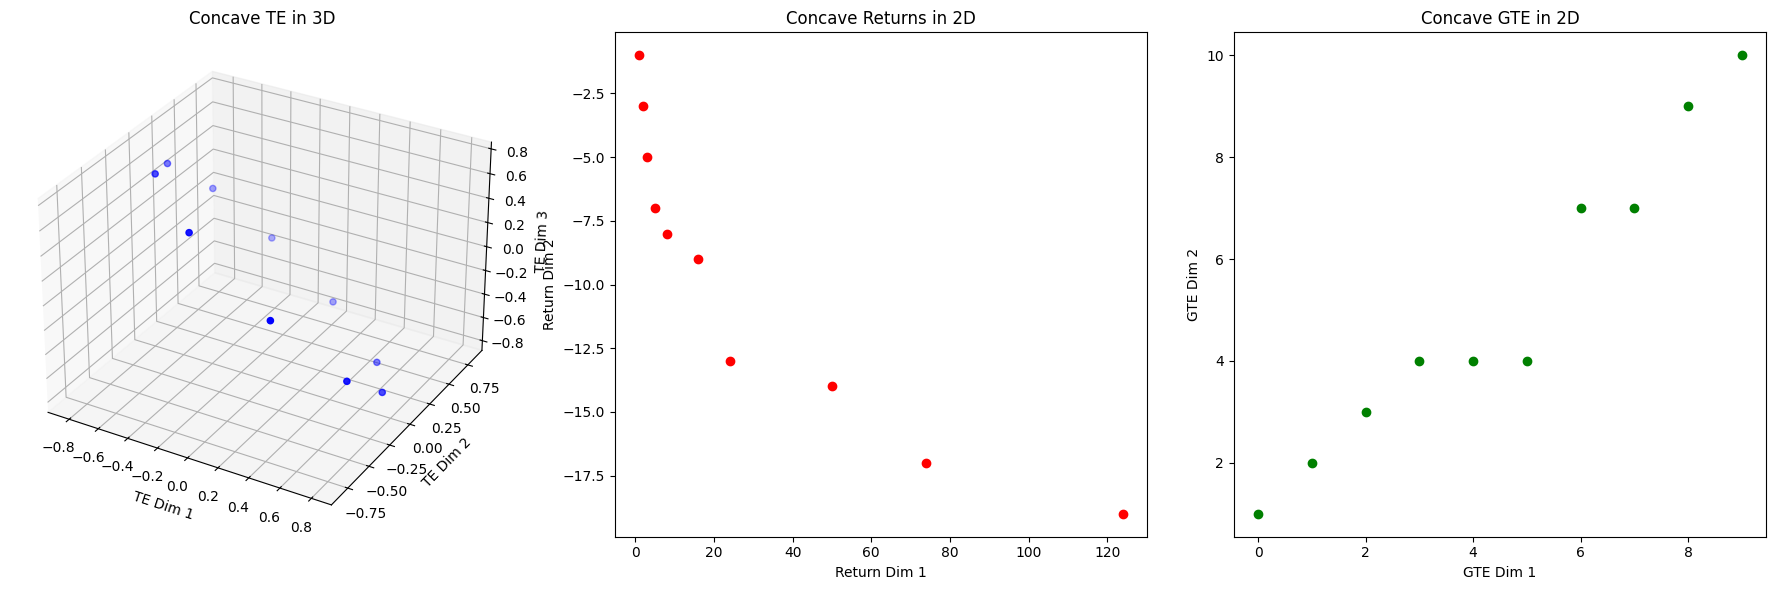

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 6))

# 3D scatter for transformer embeddings
ax1 = fig.add_subplot(131, projection="3d")
ax1.scatter(all_t_emb_3D_concave[:,0], all_t_emb_3D_concave[:,1], all_t_emb_3D_concave[:,2], c="b", marker="o")
ax1.set_title("Concave TE in 3D")
ax1.set_xlabel("TE Dim 1")
ax1.set_ylabel("TE Dim 2")
ax1.set_zlabel("TE Dim 3")

# 2D scatter for returns
ax2 = fig.add_subplot(132)
ax2.scatter(all_returns_concave[:,0], all_returns_concave[:,1], c="r", marker="o")
ax2.set_title("Concave Returns in 2D")
ax2.set_xlabel("Return Dim 1")
ax2.set_ylabel("Return Dim 2")

# 2D scatter for ground truth embeddings
ax3 = fig.add_subplot(133)
ax3.scatter(all_gt_emb_concave[:,0], all_gt_emb_concave[:,1], c="g", marker="o")
ax3.set_title("Concave GTE in 2D")
ax3.set_xlabel("GTE Dim 1")
ax3.set_ylabel("GTE Dim 2")

plt.tight_layout()
plt.show()

## Lipschitz Histograms


Computing Lipschitz constant between policy 0 and 1
4.123105625617661
18.027756377319946
Lipshitz: 4.372373160976031
Lipschitz constant for policy 0 ([124. -19.], [ 9 10]) to 1 ([120. -18.], [-9  9]): 4.372373160976031, d_obj: 4.123105625617661, d_emb: 18.027756377319946
Computing Lipschitz constant between policy 1 and 2
95.08417323613851
2.8284271247461903
Lipshitz: 0.02974656063656232
Lipschitz constant for policy 1 ([120. -18.], [-9  9]) to 2 ([ 25. -14.], [-7  7]): 0.02974656063656232, d_obj: 95.08417323613851, d_emb: 2.8284271247461903
Computing Lipschitz constant between policy 2 and 3
1.4142135623730951
13.0
Lipshitz: 9.192388155425117
Lipschitz constant for policy 2 ([ 25. -14.], [-7  7]) to 3 ([ 24. -13.], [6 7]): 9.192388155425117, d_obj: 1.4142135623730951, d_emb: 13.0
Computing Lipschitz constant between policy 3 and 4
17.72004514666935
10.44030650891055
Lipshitz: 0.5891805817928689
Lipschitz constant for policy 3 ([ 24. -13.], [6 7]) to 4 ([ 7. -8.], [-4  4]): 0.589180581

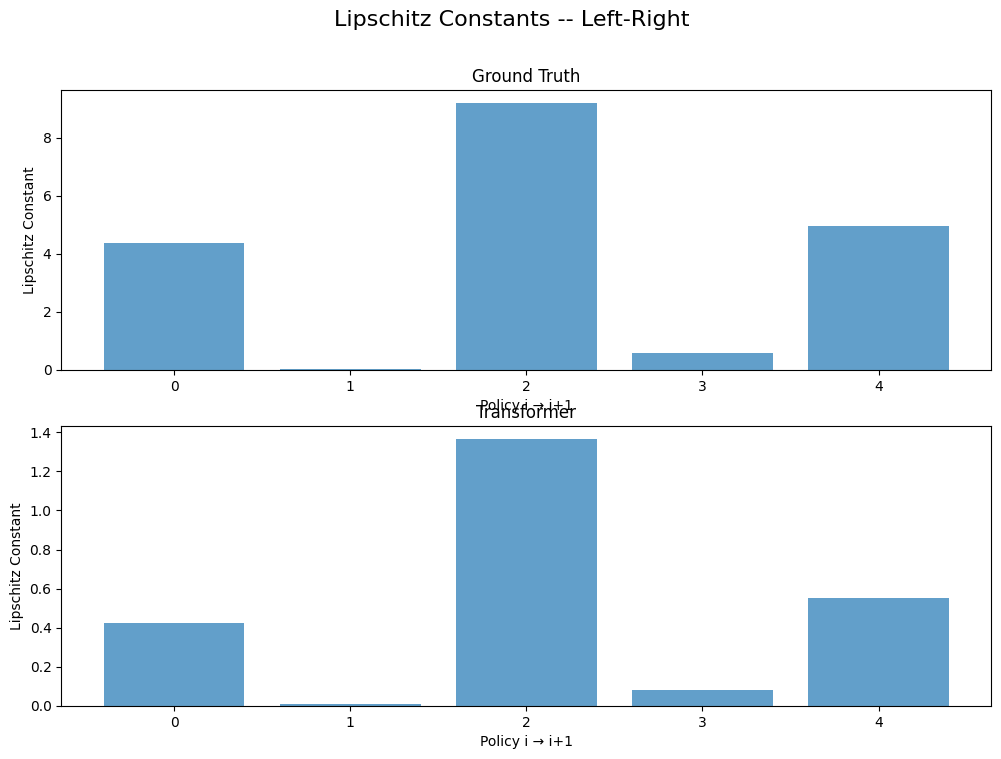

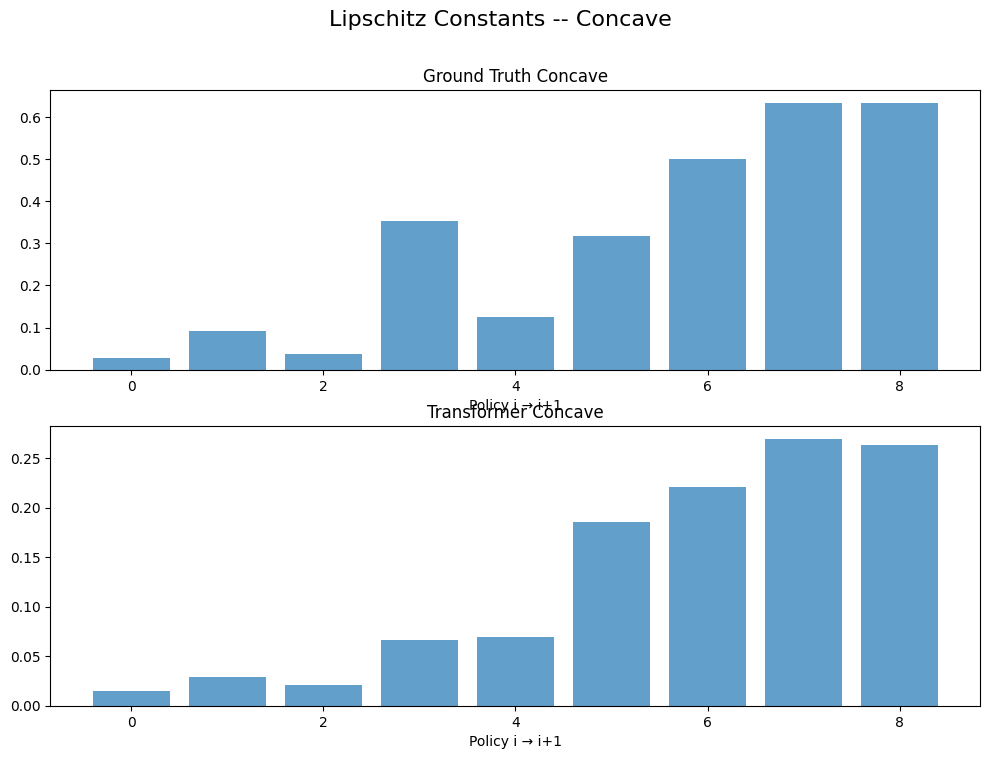

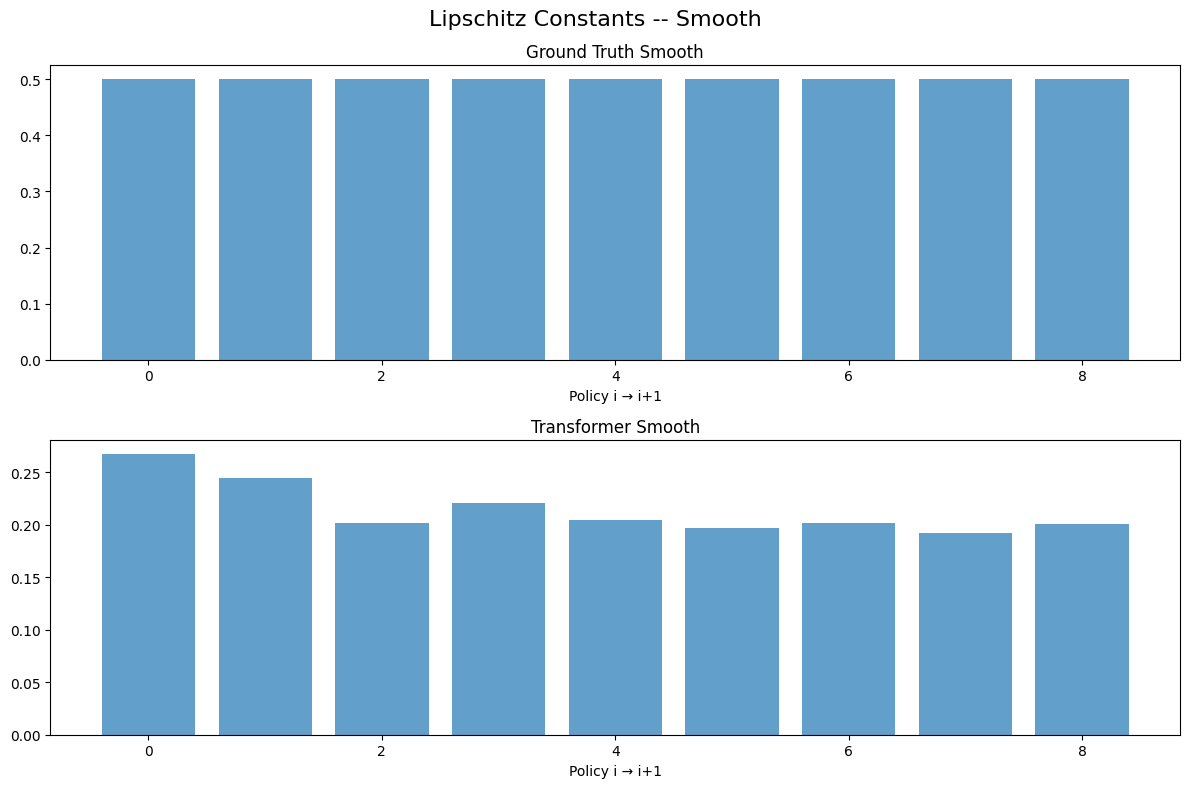

In [11]:
# Makes a histogram of the Lipschitz constants of the GTE embeddings vs the returns
import matplotlib.pyplot as plt

from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants

lipschitz_constants_lr_gt, d_objs_lr_gt, d_embs_lr_gt, _, _ = compute_lipschitz_constants(pareto_frontier=all_returns_lr, embeddings=all_gt_emb)
lipschitz_constants_concave_gt, d_objs_concave_gt, d_embs_concave_gt, _, _ = compute_lipschitz_constants(pareto_frontier=all_returns_concave, embeddings=all_gt_emb_concave)

lipschitz_constants_lr_t, d_objs_lr_t, d_embs_lr_t, _, _ = compute_lipschitz_constants(pareto_frontier=all_returns_lr, embeddings=all_t_emb_3D)
lipschitz_constants_concave_t, d_objs_concave_t, d_embs_concave_t, _, _ = compute_lipschitz_constants(pareto_frontier=all_returns_concave, embeddings=all_t_emb_3D_concave)

lipschitz_constants_smooth_gt, d_objs_smooth_gt, d_embs_smooth_gt, _, _ = compute_lipschitz_constants(pareto_frontier=all_returns_smooth, embeddings=all_gt_emb_smooth)
lipschitz_constants_smooth_t, d_objs_smooth_t, d_embs_smooth_t, _, _ = compute_lipschitz_constants(pareto_frontier=all_returns_smooth, embeddings=all_t_emb_smooth_new)

print("Concave front", all_returns_concave)
print("Left-Right front", all_returns_lr)
print(f"Lipschitz constants Left-Right: {lipschitz_constants_lr_gt}")
print(f"Lipschitz constants Concave: {lipschitz_constants_concave_gt}")
print(f"Lipschitz constants Ground Truth Smooth: {lipschitz_constants_smooth_gt}")
print(f"Lipschitz constants Transformer Left-Right: {lipschitz_constants_lr_t}")
print(f"Lipschitz constants Transformer Concave: {lipschitz_constants_concave_t}")
print(f"Lipschitz constants Transformer Smooth: {lipschitz_constants_smooth_t}")


# Create 2x1 grid with shared y-axis
fig, axs = plt.subplots(2, figsize=(12, 8))
fig2, axs2 = plt.subplots(2, figsize=(12, 8))
fig3, axs3 = plt.subplots(2, figsize=(12, 8))


# --- Plot 1: Left-Right ---
fig.suptitle("Lipschitz Constants -- Left-Right", fontsize=16)
axs[0].bar(np.arange(len(lipschitz_constants_lr_gt)), lipschitz_constants_lr_gt, alpha=0.7)
axs[0].set_title("Ground Truth")
axs[0].set_ylabel("Lipschitz Constant")
axs[0].set_xlabel("Policy i → i+1")

axs[1].bar(np.arange(len(lipschitz_constants_lr_t)), lipschitz_constants_lr_t, alpha=0.7)
axs[1].set_title("Transformer")
axs[1].set_ylabel("Lipschitz Constant")
axs[1].set_xlabel("Policy i → i+1")
plt.tight_layout()  # leave space for suptitle

# --- Plot 2: Concave ---
fig2.suptitle("Lipschitz Constants -- Concave", fontsize=16)
axs2[0].bar(np.arange(len(lipschitz_constants_concave_gt)), lipschitz_constants_concave_gt, alpha=0.7)
axs2[0].set_title("Ground Truth Concave")
axs2[0].set_xlabel("Policy i → i+1")

axs2[1].bar(np.arange(len(lipschitz_constants_concave_t)), lipschitz_constants_concave_t, alpha=0.7)
axs2[1].set_title("Transformer Concave")
axs2[1].set_xlabel("Policy i → i+1")
plt.tight_layout()  # leave space for suptitle

# --- Plot 3: Smooth ---
fig3.suptitle("Lipschitz Constants -- Smooth", fontsize=16)
axs3[0].bar(np.arange(len(lipschitz_constants_smooth_gt)), lipschitz_constants_smooth_gt, alpha=0.7)
axs3[0].set_title("Ground Truth Smooth")
axs3[0].set_xlabel("Policy i → i+1")
axs3[1].bar(np.arange(len(lipschitz_constants_smooth_t)), lipschitz_constants_smooth_t, alpha=0.7)
axs3[1].set_title("Transformer Smooth")
axs3[1].set_xlabel("Policy i → i+1")

plt.tight_layout()  # leave space for suptitle
plt.show()




Distance between points in objective space and embedding space
Distance 0 and 1 in objective space: 4.123105625617661
Distance 0 and 1 in embedding space: 1.7444185920385595
Distance 1 and 2 in objective space: 95.08417323613851
Distance 1 and 2 in embedding space: 0.772363143104345
Distance 2 and 3 in objective space: 1.4142135623730951
Distance 2 and 3 in embedding space: 1.9317339003318845
Distance 3 and 4 in objective space: 17.72004514666935
Distance 3 and 4 in embedding space: 1.4616181535541122
Distance 4 and 5 in objective space: 1.4142135623730951
Distance 4 and 5 in embedding space: 0.7821034029003487


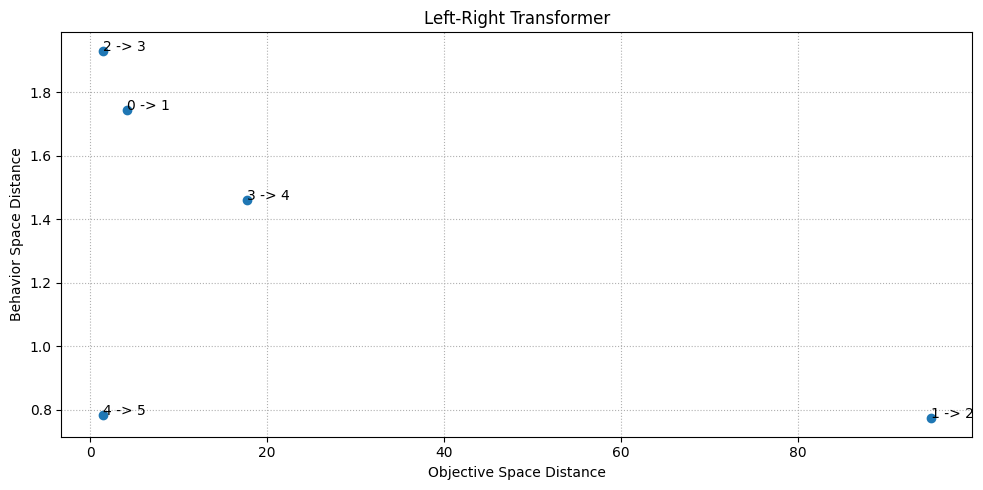

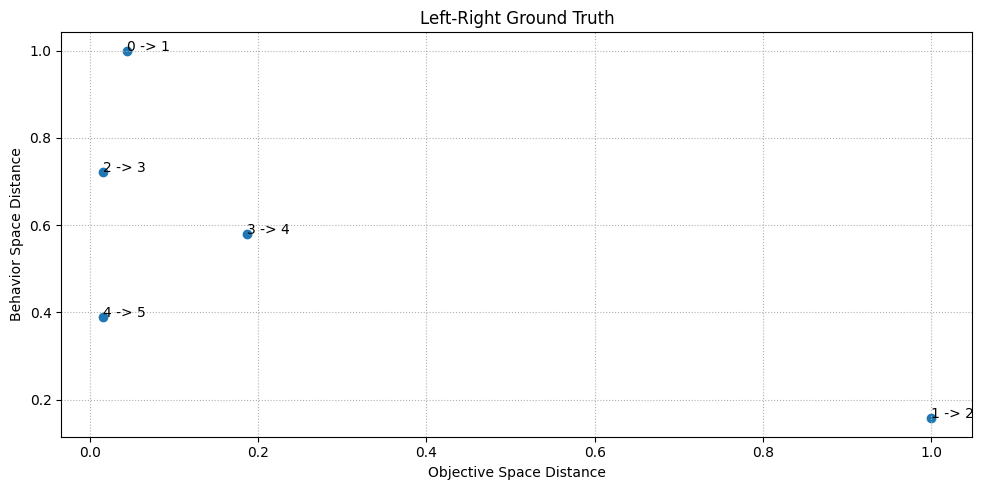

In [12]:
# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
# Create two separate figures for parallel viewing
data = d_objs_lr_t, d_embs_lr_t
data_gt = d_objs_lr_gt, d_embs_lr_gt
data_lipschitz = lipschitz_constants_lr_t, lipschitz_constants_lr_gt
instance = "Left-Right"

print("Distance between points in objective space and embedding space")
for i in range(len(data[0])):
    print(f"Distance {i} and {i+1} in objective space: {data[0][i]}")
    print(f"Distance {i} and {i+1} in embedding space: {data[1][i]}")

fig1, ax1 = plt.subplots(figsize=(10, 5))
# data = data[0] / np.max(data[0]), data[1] / np.max(data[1])
ax1.scatter(data[0], data[1])
ax1.set_xlabel("Objective Space Distance")
ax1.set_ylabel("Behavior Space Distance")
ax1.set_title(f"{instance} Transformer")
# add index as text labels
for i, txt in enumerate(range(len(data[0]))):
    ax1.annotate(f"{i} -> {i+1}", (data[0][i], data[1][i]))



plt.grid(True, linestyle=":")
plt.tight_layout()

# now the ground truth in a different plot
fig2, ax2 = plt.subplots(figsize=(10, 5))
#normalize the data
data_gt = data_gt[0] / np.max(data_gt[0]), data_gt[1] / np.max(data_gt[1])

ax2.scatter(data_gt[0], data_gt[1])
ax2.set_xlabel("Objective Space Distance")
ax2.set_ylabel("Behavior Space Distance")
ax2.set_title(f"{instance} Ground Truth")
# add index as text labels
for i, txt in enumerate(range(len(data_gt[0]))):
    ax2.annotate(f"{i} -> {i+1}", (data_gt[0][i], data_gt[1][i]))


plt.grid(True, linestyle=":")
plt.tight_layout()

plt.show()

